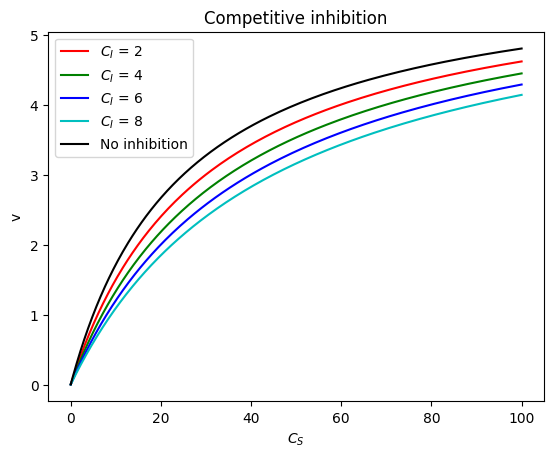

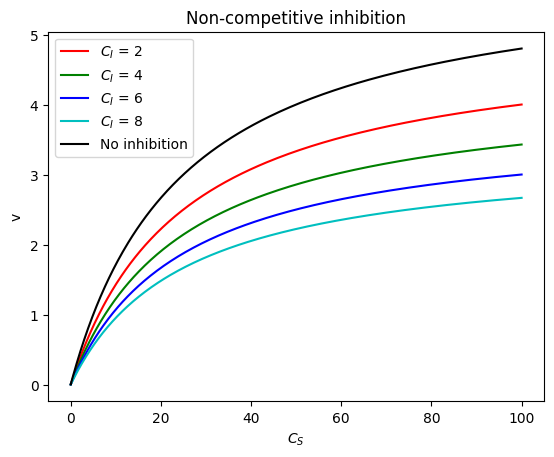

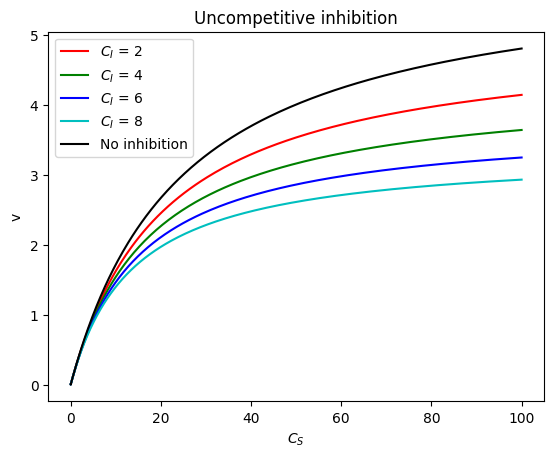

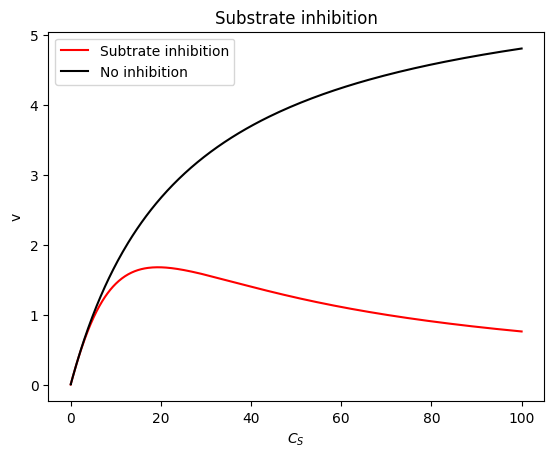

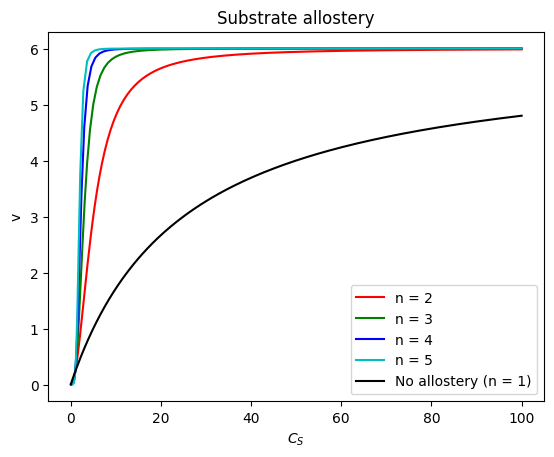

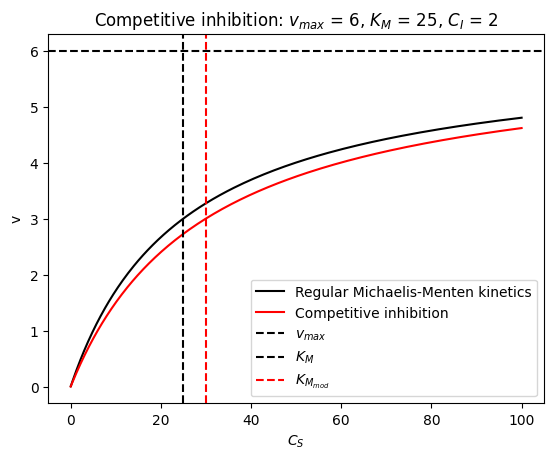

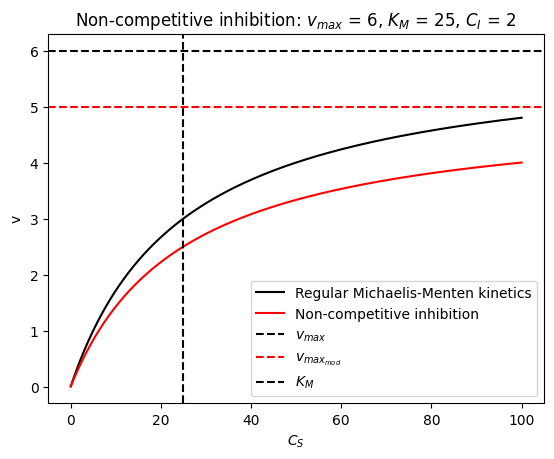

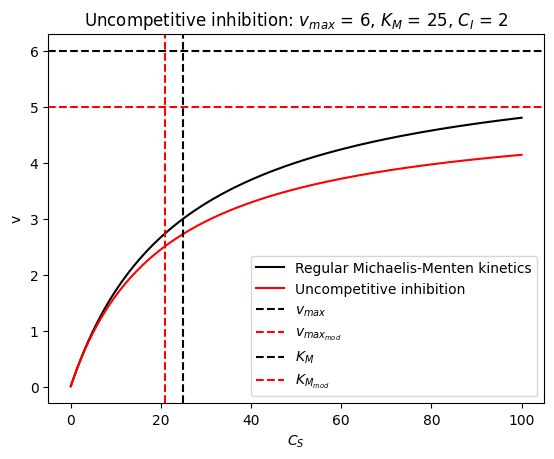

In [1]:
#Importing the requisite libraries
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from cycler import cycler

#Defining all the kinetic models

#Regular Michaelis-Menten expression
def michaelis(S,t):
    dSdt = -(vmax*S)/(Km + S)
    return dSdt

#Competitive inhibition
def competitive(S,t):
    dSdt = -(vmax*S)/(Km*(1 + Icomp/Ki) + S)
    return dSdt

#Non-competitive inhibition
def noncompetitive(S,t):
    dSdt = -(vmax*S)/((Km + S)*(1 + Inc/Ki))
    return dSdt

#Uncompetitive inhibition
def uncompetitive(S,t):
    dSdt = -(vmax*S)/(Km + S*(1 + Iuc/Ki))
    return dSdt

#Substrate inhibition
def substrateinhibition(S,t):
    dSdt = -(vmax*S)/(Km + S + (S**2)/Ks)
    return dSdt

#Substrate allostery
def hill(S,t):
    dSdt = -(vmax*(S**n))/(Km + (S**n))
    return dSdt

#Initial condition
t = np.linspace(0,150,1000)
S0 = 100

#Kinetic parameters
vmax = 6 #M/min
Km = 25 #M
Ki = 10
Ks = 15

#Solving the ODEs

#Standard Michaelis-Menten kinetics
S = odeint(michaelis, S0, t)
v = (vmax*S)/(Km + S)

#Competitive inhibition
for i in range(1, 5):
    Icomp = 2*i
    Scomp = odeint(competitive, S0, t)
    vcomp = (vmax*Scomp)/(Km*(1 + Icomp/Ki) + Scomp)
    plt.rc('axes', prop_cycle=(cycler('color', ['r', 'g', 'b', 'c'])))
    plt.plot(Scomp, vcomp, label = "$C_I$ = %i" %Icomp)
plt.plot(S, v, 'k', label = 'No inhibition')
plt.xlabel("$C_S$")
plt.ylabel("v")
plt.title('Competitive inhibition')
plt.legend()
plt.show()

#Non-competitive inhibition
for i in range(1, 5):
    Inc = 2*i
    Snc = odeint(noncompetitive, S0, t)
    vnc = (vmax*Snc)/((Km + Snc)*(1 + Inc/Ki))
    plt.rc('axes', prop_cycle=(cycler('color', ['r', 'g', 'b', 'c'])))
    plt.plot(Snc, vnc, label = "$C_I$ = %i" %Inc)
plt.plot(S, v, 'k', label = 'No inhibition')
plt.xlabel("$C_S$")
plt.ylabel("v")
plt.title('Non-competitive inhibition')
plt.legend()
plt.show()

#Uncompetitive inhibition
for i in range(1, 5):
    Iuc = 2*i
    Suc = odeint(uncompetitive, S0, t)
    vuc = (vmax*Suc)/(Km + Suc*(1 + Iuc/Ki))
    plt.rc('axes', prop_cycle=(cycler('color', ['r', 'g', 'b', 'c'])))
    plt.plot(Suc, vuc, label = "$C_I$ = %i" %Iuc)
plt.plot(S, v, 'k', label = 'No inhibition')
plt.xlabel("$C_S$")
plt.ylabel("v")
plt.title('Uncompetitive inhibition')
plt.legend()
plt.show()

#Substrate inhibition
Si = odeint(substrateinhibition, S0, t)
vi = (vmax*Si)/(Km + Si + (Si**2)/Ks)
plt.plot(Si, vi, 'r', label = 'Subtrate inhibition')
plt.plot(S, v, 'k', label = 'No inhibition')
plt.xlabel("$C_S$")
plt.ylabel("v")
plt.title('Substrate inhibition')
plt.legend()
plt.show()

#Substrate allostery
for i in range(2, 6):
    n = i
    Sa = odeint(hill, S0, t)
    va = (vmax*(Sa**n))/(Km + (Sa**n))
    plt.rc('axes', prop_cycle=(cycler('color', ['r', 'g', 'b', 'c'])))
    plt.plot(Sa, va, label = "n = %i" %n)
plt.plot(S, v, 'k', label = 'No allostery (n = 1)')
plt.xlabel("$C_S$")
plt.ylabel("v")
plt.title('Substrate allostery')
plt.legend()
plt.show()

#Let's look at the plots in terms of vmax and Km for fixed CI

Icomp = 2
Inc = 2
Iuc = 2

S1 = odeint(michaelis, S0, t)
S2 = odeint(competitive, S0, t)
S3 = odeint(noncompetitive, S0, t)
S4 = odeint(uncompetitive, S0, t)

v1 = (vmax*S)/(Km + S1)
v2 = (vmax*S2)/(Km*(1 + Icomp/Ki) + S2) 
v3 = (vmax*S3)/((Km + S3)*(1 + Inc/Ki))  
v4 = (vmax*S4)/(Km + S4*(1 + Iuc/Ki))

Kmmod = Km*(1 + Icomp/Ki) 
vmaxmod = vmax/(1 + Icomp/Ki) 
Kmmod2 = Km/(1 + Icomp/Ki) 

#Plots
plt.plot(S1, v1, "k", label = 'Regular Michaelis-Menten kinetics')
plt.plot(S2, v2, "r", label = 'Competitive inhibition')
plt.axhline(y=vmax, color='k', linestyle='--', label = '$v_{max}$')
plt.axvline(x=Km, color='k',linestyle='--', label = '$K_M$')
plt.axvline(x=Kmmod, color='r',linestyle='--', label = '$K_{M_{mod}}$')
plt.xlabel("$C_S$")
plt.ylabel("v")
plt.title('Competitive inhibition: $v_{max}$ = 6, $K_M$ = 25, $C_I$ = 2')
plt.legend()
plt.show()

plt.plot(S1, v1, "k", label = 'Regular Michaelis-Menten kinetics')
plt.plot(S3, v3, "r", label = 'Non-competitive inhibition')
plt.axhline(y=vmax, color='k', linestyle='--', label = '$v_{max}$')
plt.axhline(y=vmaxmod, color='r',linestyle='--',label = '$v_{max_{mod}}$')
plt.axvline(x=Km, color='k',linestyle='--', label = '$K_M$')
plt.xlabel("$C_S$")
plt.ylabel("v")
plt.title('Non-competitive inhibition: $v_{max}$ = 6, $K_M$ = 25, $C_I$ = 2')
plt.legend()
plt.show()


plt.plot(S1, v1, "k", label = 'Regular Michaelis-Menten kinetics')
plt.plot(S4, v4, "r", label = 'Uncompetitive inhibition')
plt.axhline(y=vmax, color='k', linestyle='--', label = '$v_{max}$')
plt.axhline(y=vmaxmod, color='r',linestyle='--', label = '$v_{max_{mod}}$')
plt.axvline(x=Km, color='k',linestyle='--', label = '$K_M$')
plt.axvline(x=Kmmod2, color='r',linestyle='--',label = '$K_{M_{mod}}$')
plt.xlabel("$C_S$")
plt.ylabel("v")
plt.title('Uncompetitive inhibition: $v_{max}$ = 6, $K_M$ = 25, $C_I$ = 2')
plt.legend()
plt.show()